# Import des librairies et packages

In [1]:
import pandas as pd
import polars as pl
import polars.selectors as cs

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import time

In [2]:
from sklearn.cluster import KMeans

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler

from sklearn.utils.class_weight import compute_class_weight


In [3]:
from src.import_.read_file import  read_file, df_dtypes

from src.exploratory.explore_data import show_values_counts_columns, analyse_univariee_qualitative, describe_variables_numeriques, controle_regroupements_modalites, resume_production_pv_positive, separer_variables_quali_bin_quanti

from src.exploratory.plots import plot_pareto_modalites, plot_boxplot_and_hist, plot_target_dpe, plot_dist, boxplot_vs_target, plot_missing_train_test

from src.exploratory.bivariee import taux_energivore_par_modalite, tableau_quali_quali

from src.prepro.nettoyage import nettoyage_metier
from src.prepro.regrouper_modalites import creer_target_dpe_3_classes
from src.prepro.modalite_groupings import MODALITES_GROUPINGS
from src.prepro.regrouper_modalites import appliquer_regroupements_modalites

from src.prepro.prepro_ import split_train_test_polars, elbow_plot, fit_kmeans_pv_train, appliquer_kmeans_pv, colonnes_avec_missing, imputer_apres_selection, separer_colonnes_pipeline

from src.stats_.stats_ import tester_variables_avec_target

from src.models.models import afficher_classification_report, plot_confusion_matrix, evaluer_lgb_class_weights

In [4]:
import lightgbm as lgb
from sklearn.linear_model import LogisticRegression

In [5]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    balanced_accuracy_score,
    accuracy_score,
    f1_score,
)

In [6]:
pl.Config.set_tbl_rows(-1)
pl.Config.set_tbl_cols(-1)
pl.Config.set_tbl_width_chars(-1)
pl.Config.set_fmt_str_lengths(100)

polars.config.Config

In [7]:
PATH_DATA = "resources/dpe_hauts_de_france_2025-07-01_to_2025-12-31_half.csv"
TARGET = "etiquette_dpe"
CLASSES_DPE = ["A", "B", "C", "D", "E", "F", "G"]

DPE_COLORS = {
    "A": "#008A4B",
    "B": "#58B957",
    "C": "#C7D93D",
    "D": "#F4E04D",
    "E": "#F5A623",
    "F": "#E85D27",
    "G": "#C62828",
}

RANDOM_STATE = 42

# Lecture et Visualisation des données

In [8]:
data, num_cols, cat_cols = read_file(PATH_DATA, TARGET)
df = data.clone()

### Import des données

Le jeu de données contient **57826 lignes** et **46 colonnes**.

### Réduction de la taille du DataFrame

Taille du DataFrame avant réduction : **37.71 MB**

Taille du DataFrame après réduction : **34.35 MB**

Réduction mémoire : **8.92%**

### Aperçu des données importées

etiquette_dpe,numero_dpe,date_etablissement_dpe,code_region_ban,code_departement_ban,code_postal_ban,code_insee_ban,nom_commune_ban,zone_climatique,classe_altitude,type_batiment,methode_application_dpe,periode_construction,annee_construction,surface_habitable_immeuble,nombre_niveau_immeuble,nombre_appartement,numero_etage_appartement,hauteur_sous_plafond,classe_inertie_batiment,qualite_isolation_enveloppe,qualite_isolation_murs,qualite_isolation_menuiseries,qualite_isolation_plancher_bas,qualite_isolation_plancher_haut_comble_perdu,type_installation_chauffage,type_installation_chauffage_n1,configuration_installation_chauffage_n1,type_generateur_chauffage_principal,type_generateur_n1_installation_n1,type_energie_principale_chauffage,type_energie_generateur_n1_installation_n1,type_emetteur_installation_chauffage_n1,usage_generateur_n1_installation_n1,type_installation_ecs,type_installation_ecs_n1,configuration_installation_ecs_n1,type_generateur_n1_ecs_n1,type_generateur_chauffage_principal_ecs,type_energie_principale_ecs,type_energie_generateur_n1_ecs_n1,usage_generateur_n1_ecs_n1,volume_stockage_generateur_n1_ecs_n1,ventilation_posterieure_2012,type_installation_solaire_n1,production_electricite_pv_kwhep_par_an
str,str,str,u8,u8,u32,u32,str,str,str,str,str,str,f32,f32,f32,f32,f32,f32,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,f32,u8,str,f32
"""C""","""2559E3504406H""","""2025-11-05""",32,59,59320,59286,"""Haubourdin""","""H1a""","""inférieur à 400m""","""maison""","""dpe maison individuelle""","""1948-1974""",null,null,null,null,0.0,2.5,"""Lourde""","""très bonne""","""très bonne""","""bonne""","""très bonne""","""très bonne""",null,"""installation individuelle""","""Installation de chauffage simple""","""Chaudière gaz à condensation après 2015""","""Chaudière gaz à condensation après 2015""","""Gaz naturel""","""Gaz naturel""","""Radiateur monotube sans robinet thermostatique sur réseau individuel eau chaude basse ou moyenne tem…","""chauffage + ecs""",null,"""installation individuelle""","""Un seul système d'ECS sans solaire""","""Chaudière gaz à condensation après 2015""","""Chaudière gaz à condensation après 2015""","""Gaz naturel""","""Gaz naturel""","""chauffage + ecs""",0.0,1,"""Non affecté""",0.0
"""F""","""2559E2432688J""","""2025-07-24""",32,59,59360,59136,"""Le Cateau-Cambrésis""","""H1a""","""inférieur à 400m""","""maison""","""dpe maison individuelle""","""avant 1948""",null,null,null,null,0.0,2.6,"""Lourde""","""insuffisante""","""insuffisante""","""moyenne""","""insuffisante""",null,null,"""installation individuelle""","""Installation de chauffage simple""",null,"""Chaudière gaz à condensation 2001-2015""","""Gaz naturel""","""Gaz naturel""","""Radiateur bitube avec robinet thermostatique sur réseau individuel eau chaude haute température(sup …","""chauffage + ecs""",null,"""installation individuelle""","""Un seul système d'ECS sans solaire""","""Chaudière gaz à condensation 2001-2015""",null,"""Gaz naturel""","""Gaz naturel""","""chauffage + ecs""",0.0,0,"""Non affecté""",0.0
"""C""","""2502E3087497D""","""2025-09-30""",32,2,2170,2558,"""Le Nouvion-en-Thiérache""","""H1a""","""inférieur à 400m""","""appartement""","""dpe appartement individuel""","""1978-1982""",null,512.299988,null,1.0,0.0,2.5,"""Moyenne""","""très bonne""","""insuffisante""","""très bonne""","""insuffisante""",null,"""individuel""","""installation individuelle""","""Installation de chauffage simple""",null,"""Panneau rayonnant électrique NFC, NF** et NF***""","""Électricité""","""Électricité""","""Panneau rayonnant NFC, NF** et NF***""","""chauffage""","""individuel""","""installation individuelle""","""Un seul système d'ECS sans solaire""","""CET sur air ambiant (sur local non chauffé) après 2014""",null,"""Électricité""","""Électricité""","""ecs""",150.0,1,"""Non affecté""",0.0
"""E""","""2502E3013330O""","""2025-09-23""",32,2,2000,2408,"""Laon""","""H1a""","""inférieur à 400m""","""maison"""

### Que vaut notre target ?

etiquette_dpe,Pourcentage
str,f64
"""A""",0.94
"""B""",3.26
"""C""",36.12
"""D""",35.52
"""E""",15.03
"""F""",6.1
"""G""",3.03


In [9]:
df_dtypes(df)

### Les différents types du df

Variables,Types
str,str
"""etiquette_dpe""","""String"""
"""numero_dpe""","""String"""
"""date_etablissement_dpe""","""String"""
"""code_region_ban""","""UInt8"""
"""code_departement_ban""","""UInt8"""
"""code_postal_ban""","""UInt32"""
"""code_insee_ban""","""UInt32"""
"""nom_commune_ban""","""String"""
"""zone_climatique""","""String"""


### Catégorisation des types du df

Type,Nombre,Pourcentage
object,i64,f64
String,33,71.74
UInt8,3,6.52
UInt32,2,4.35
Float32,8,17.39


In [10]:
show_values_counts_columns(df)

### Modalités distinctes et valeurs manquantes par variable

Variable,Nombre de lignes,% valeurs manquantes,Modalités distinctes,% modalités distinctes
str,i64,f64,i64,f64
"""nombre_niveau_immeuble""",57826,76.42,19,0.03
"""surface_habitable_immeuble""",57826,68.46,3858,6.67
"""type_generateur_chauffage_principal_ecs""",57826,67.75,73,0.13
"""type_generateur_chauffage_principal""",57826,67.67,93,0.16
"""qualite_isolation_plancher_haut_comble_perdu""",57826,52.86,4,0.01
"""annee_construction""",57826,51.93,204,0.35
"""nombre_appartement""",57826,50.91,135,0.23
"""type_installation_chauffage""",57826,47.75,3,0.01
"""type_installation_ecs""",57826,47.75,3,0.01


# Première suppression de variables

In [11]:
var_to_drop1 = ["nombre_niveau_immeuble", "surface_habitable_immeuble", "type_generateur_chauffage_principal_ecs", "type_generateur_chauffage_principal", "qualite_isolation_plancher_haut_comble_perdu", "annee_construction", "nombre_appartement", "type_installation_chauffage", "type_installation_ecs", ]

var_const = ["numero_dpe"]

var_dpe = ["methode_application_dpe", "date_etablissement_dpe"]

var_id = ["code_region_ban", "code_departement_ban", "code_postal_ban", "code_insee_ban", "nom_commune_ban"]

var_to_drop = [*var_const, *var_dpe, *var_id]

cat_cols = list(set(cat_cols) - {*var_to_drop, *var_to_drop1})
num_cols = list(set(num_cols) - {*var_to_drop, *var_to_drop1})

In [12]:
df = df.drop(var_to_drop1)

In [13]:
CAT_VAR_TO_ANALYSE = ["zone_climatique", "type_batiment", "type_energie_principale_chauffage"]

NUM_VAR_TO_ANALYSE = ["numero_etage_appartement", "production_electricite_pv_kwhep_par_an", "hauteur_sous_plafond"]


# Analyse univariée

## Variables catégorielles

In [14]:
analyse_univariee_qualitative(df, col="zone_climatique")

## Analyse univariée : `zone_climatique`


        - Nombre de lignes : **57826**
        - Nombre de modalités distinctes : **8**
        - Pourcentage de valeurs manquantes : **0.0 %**
        

zone_climatique,Pourcentage
str,f64
"""H1a""",99.86
"""H3""",0.05
"""H1b""",0.03
"""H1c""",0.03
"""H2a""",0.01
"""H2c""",0.01
"""H2b""",0.01
"""H2d""",0.0


In [15]:
analyse_univariee_qualitative(df, col="type_energie_principale_chauffage")

## Analyse univariée : `type_energie_principale_chauffage`


        - Nombre de lignes : **57826**
        - Nombre de modalités distinctes : **11**
        - Pourcentage de valeurs manquantes : **0.0 %**
        

type_energie_principale_chauffage,Pourcentage
str,f64
"""Gaz naturel""",53.58
"""Électricité""",31.57
"""Réseau de Chauffage urbain""",7.89
"""Fioul domestique""",3.22
"""Bois – Granulés (pellets) ou briquettes""",1.74
"""Bois – Bûches""",1.49
"""GPL""",0.3
"""Charbon""",0.1
"""Propane""",0.09


In [16]:
var_doublons = ["type_energie_generateur_n1_installation_n1", "type_energie_generateur_n1_ecs_n1"]

var_to_drop = [*var_to_drop, *var_doublons]

In [17]:
df.select(
    [
        pl.len().alias("nb_lignes"),

        (
            pl.col("type_energie_principale_chauffage")
            == pl.col("type_energie_generateur_n1_installation_n1")
        )
        .sum()
        .alias("nb_identiques"),

        (
            pl.col("type_energie_principale_chauffage")
            != pl.col("type_energie_generateur_n1_installation_n1")
        )
        .sum()
        .alias("nb_differentes"),

        pl.col("type_energie_principale_chauffage").null_count()
        .alias("null_principale_chauffage"),

        pl.col("type_energie_generateur_n1_installation_n1").null_count()
        .alias("null_generateur_n1"),
    ]
)

nb_lignes,nb_identiques,nb_differentes,null_principale_chauffage,null_generateur_n1
u32,u32,u32,u32,u32
57826,57522,278,0,26


In [18]:
df.select(
    [
        pl.len().alias("nb_lignes"),

        (
            pl.col("type_energie_principale_ecs")
            == pl.col("type_energie_generateur_n1_ecs_n1")
        )
        .sum()
        .alias("nb_identiques"),

        (
            pl.col("type_energie_principale_ecs")
            != pl.col("type_energie_generateur_n1_ecs_n1")
        )
        .sum()
        .alias("nb_differentes"),

        pl.col("type_energie_principale_ecs").null_count()
        .alias("null_principale_chauffage"),

        pl.col("type_energie_generateur_n1_ecs_n1").null_count()
        .alias("null_generateur_n1"),
    ]
)

nb_lignes,nb_identiques,nb_differentes,null_principale_chauffage,null_generateur_n1
u32,u32,u32,u32,u32
57826,57557,42,0,227


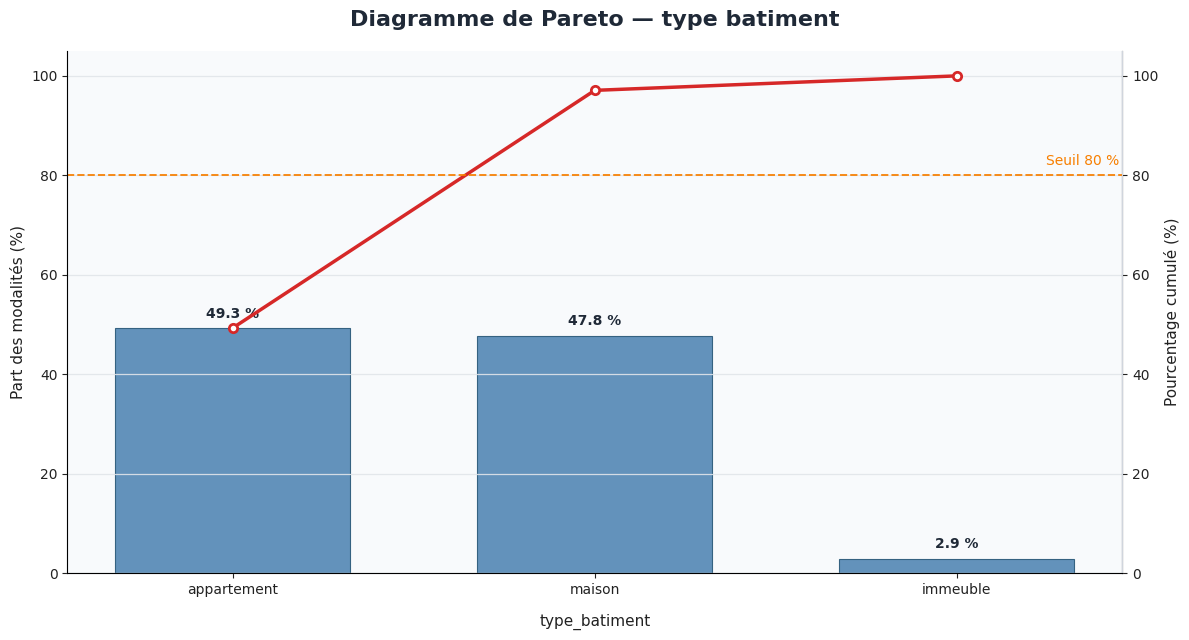

WindowsPath('src/plots/cat/pareto_type_batiment.png')

In [19]:
plot_pareto_modalites(df, col="type_batiment", top_n=10)

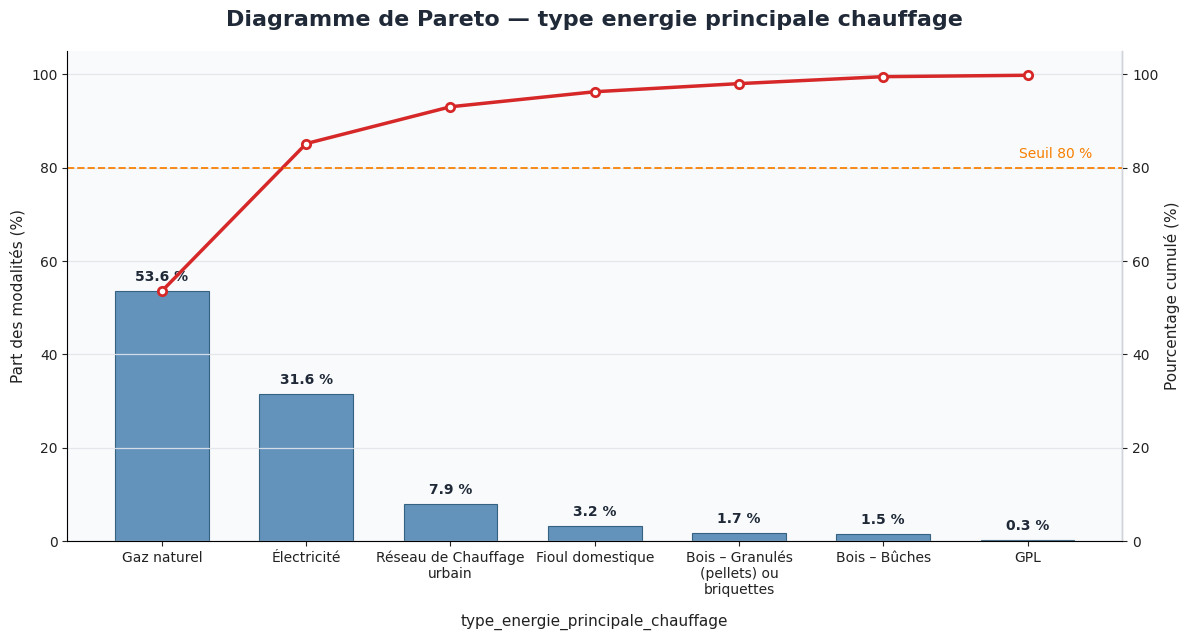

WindowsPath('src/plots/cat/pareto_type_energie_principale_chauffage.png')

In [20]:
plot_pareto_modalites(df, col="type_energie_principale_chauffage", top_n=7)

## Variables numériques

In [21]:
var_binaire = ["ventilation_posterieure_2012"]

num_cols = list(set(num_cols) - {*var_binaire, *var_id})
outlier_cols = describe_variables_numeriques(df, num_cols)


### Resume statistique des variables numériques

colonne,count,missing_count,missing_%,nb_unique,mean,std,min,q1,median,q3,max,iqr,borne_basse,borne_haute,outlier_count,outlier_%
str,i64,i64,f64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,f64
"""numero_etage_appartement""",51558,6268,10.84,19,0.15,0.681,-2.0,0.0,0.0,0.0,18.0,0.0,0.0,0.0,3493,6.04
"""volume_stockage_generateur_n1_ecs_n1""",57599,227,0.39,773,93.848,228.659,0.0,0.0,0.0,150.0,10000.0,150.0,-225.0,375.0,827,1.43
"""production_electricite_pv_kwhep_par_an""",57826,0,0.0,399,42.724,1980.189,0.0,0.0,0.0,0.0,460380.8125,0.0,0.0,0.0,586,1.01
"""hauteur_sous_plafond""",57826,0,0.0,61,2.562,1.727,1.0,2.5,2.5,2.5,240.0,0.0,2.5,2.5,16546,28.61


In [22]:
num_cols

['numero_etage_appartement',
 'volume_stockage_generateur_n1_ecs_n1',
 'production_electricite_pv_kwhep_par_an',
 'hauteur_sous_plafond']

### Visualisation des variables numériques

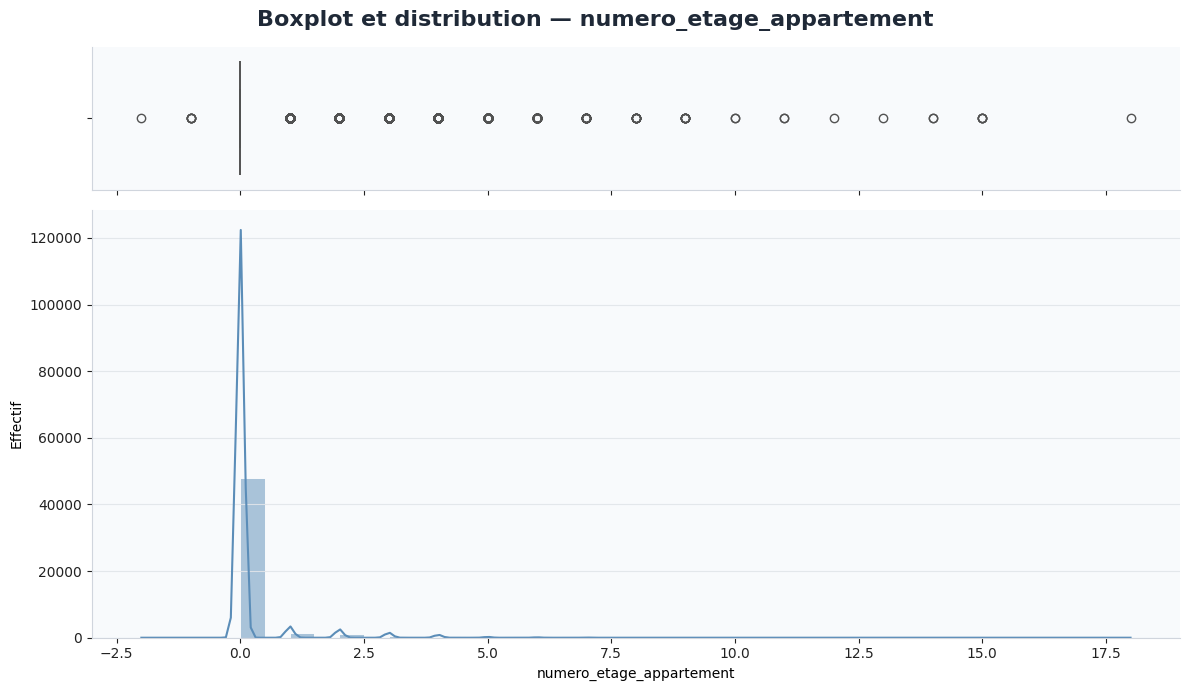

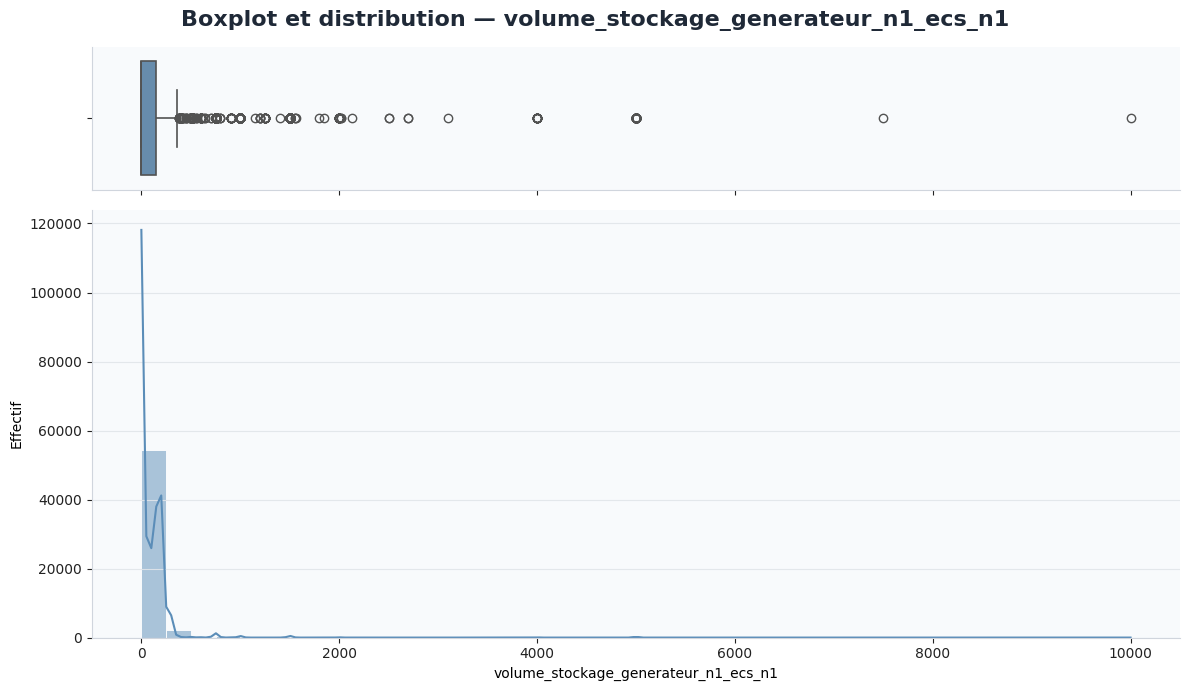

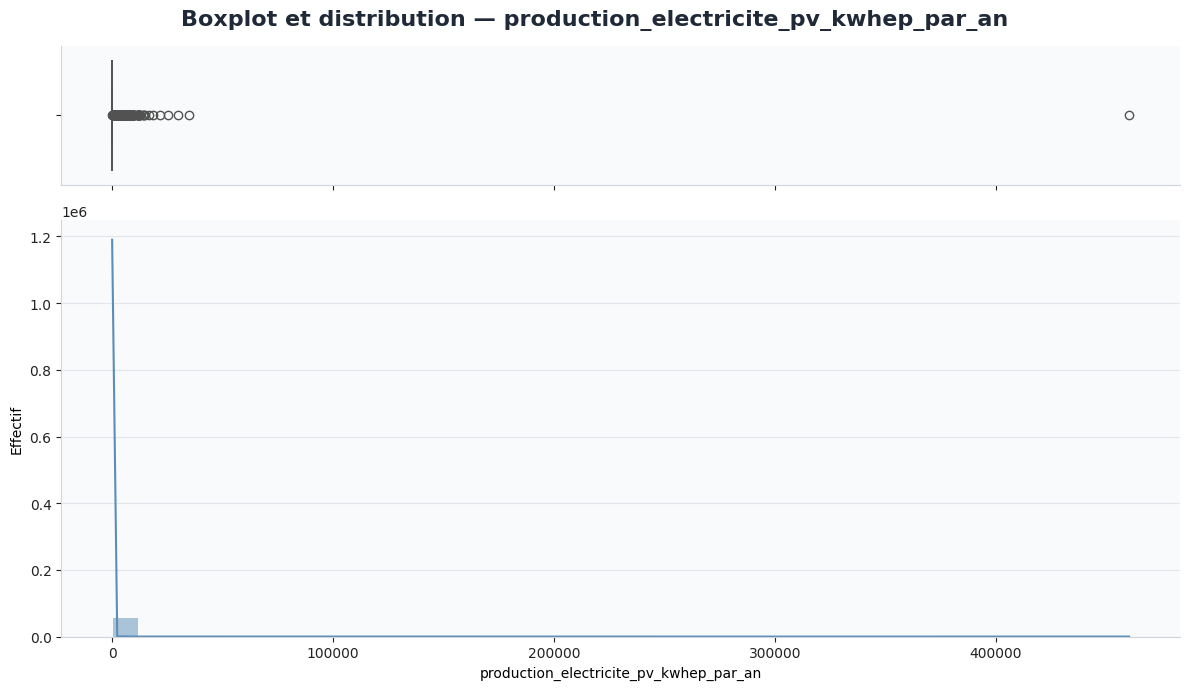

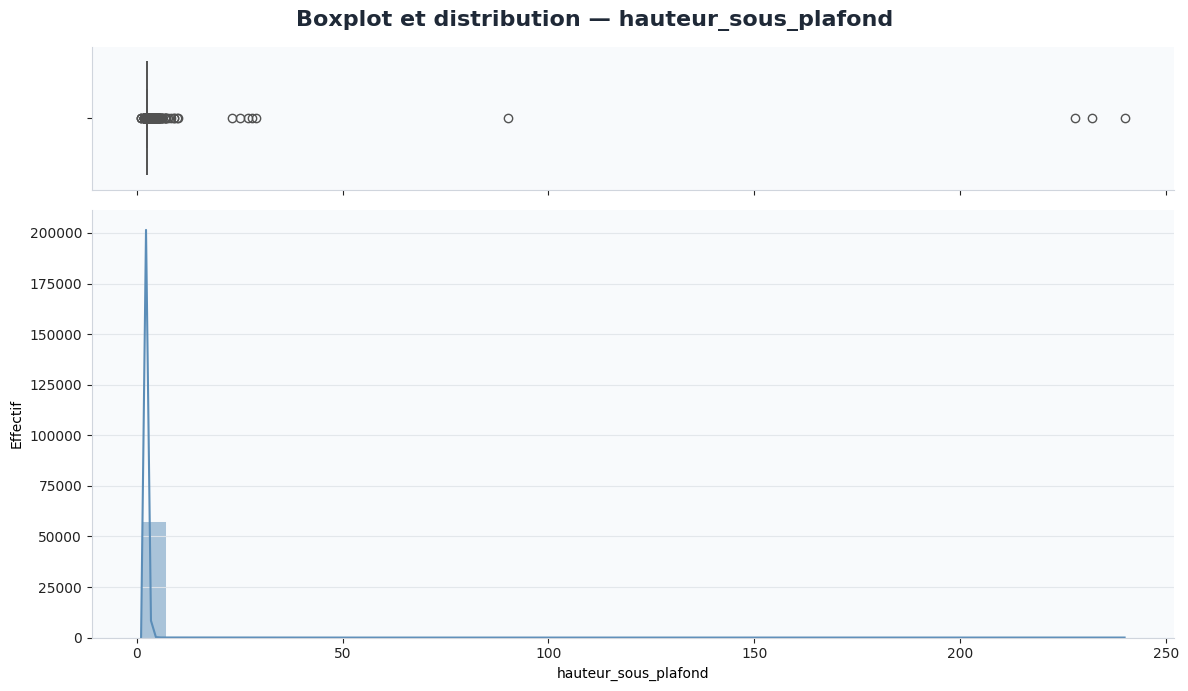

In [23]:
for col in num_cols:
    plot_boxplot_and_hist(df, col)

In [24]:
df["numero_etage_appartement"].value_counts()

numero_etage_appartement,count
f32,u32
null,6268
-2.0,1
12.0,1
9.0,8
7.0,21
5.0,96
18.0,1
11.0,2
13.0,1


In [25]:
sum(df["hauteur_sous_plafond"] > 5) + sum(df["hauteur_sous_plafond"] < 1.8)

39

# Un premier nettoyage sur les variables quantitatives avant d'aller plus loin

In [26]:
df = nettoyage_metier(df)

In [27]:
df.shape

(57103, 40)

In [28]:
new_cols_num = ["hauteur_sous_plafond_corrigee"]
var_bianire = [*var_binaire, *["has_PV"]]

num_cols = num_cols + new_cols_num

In [29]:
outlier_cols = describe_variables_numeriques(df, num_cols)

### Resume statistique des variables numériques

colonne,count,missing_count,missing_%,nb_unique,mean,std,min,q1,median,q3,max,iqr,borne_basse,borne_haute,outlier_count,outlier_%
str,i64,i64,f64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,f64
"""numero_etage_appartement""",50922,6181,10.82,19,0.15,0.681,-2.0,0.0,0.0,0.0,18.0,0.0,0.0,0.0,3427,6.0
"""volume_stockage_generateur_n1_ecs_n1""",56876,227,0.4,761,77.838,103.867,0.0,0.0,0.0,150.0,5000.0,150.0,-225.0,375.0,137,0.24
"""production_electricite_pv_kwhep_par_an""",57103,0,0.0,395,42.656,1989.671,0.0,0.0,0.0,0.0,460380.8125,0.0,0.0,0.0,582,1.02
"""hauteur_sous_plafond""",57103,0,0.0,42,2.558,1.682,1.9,2.5,2.5,2.5,240.0,0.0,2.5,2.5,16417,28.75
"""hauteur_sous_plafond_corrigee""",57103,0,0.0,42,2.545,0.173,1.9,2.5,2.5,2.5,6.0,0.0,2.5,2.5,16417,28.75


### Visualisation de la variavle hauteur_sous_plafond_corrigee

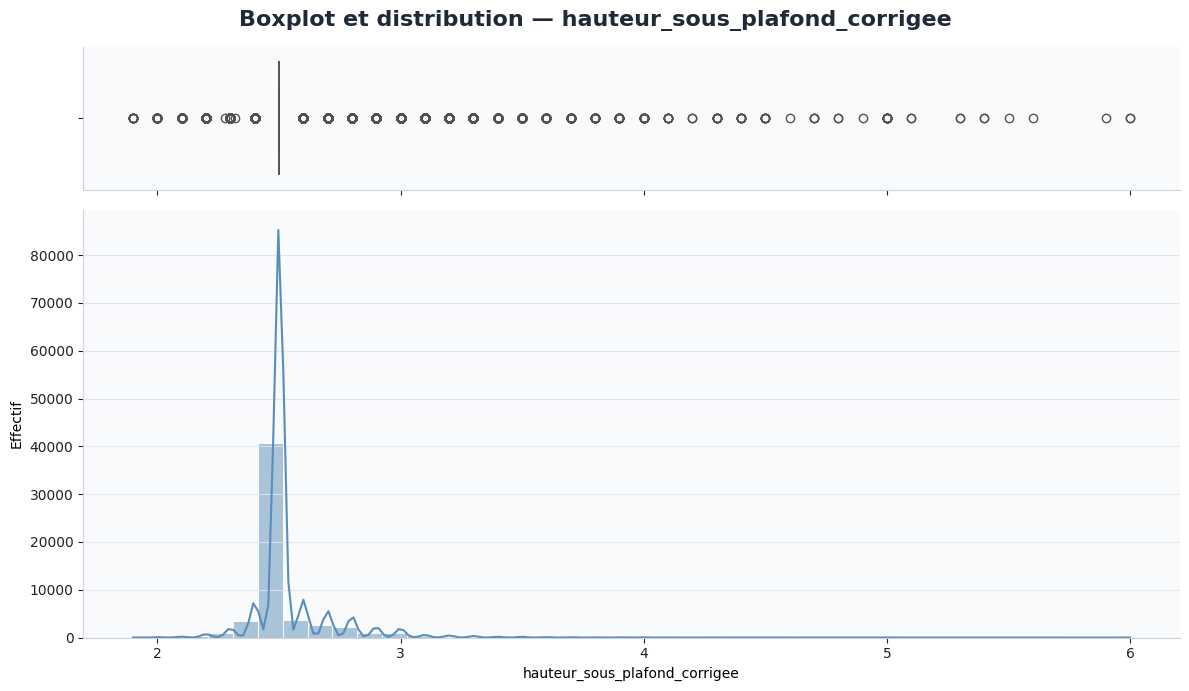

WindowsPath('src/plots/num/boxplot_distribution_hauteur_sous_plafond_corrigee.png')

In [30]:
plot_boxplot_and_hist(df, col="hauteur_sous_plafond_corrigee")

# Visualisation de la target

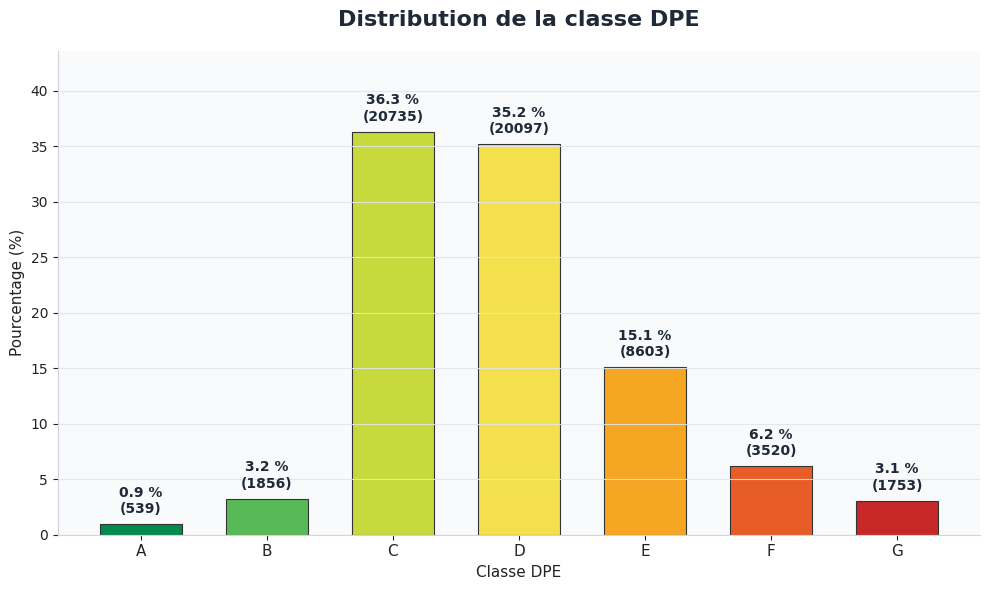

WindowsPath('src/plots/cat/distribution_etiquette_dpe.png')

In [31]:
plot_target_dpe(df, classes_dpe=CLASSES_DPE, dpe_colors=DPE_COLORS, target_col="etiquette_dpe")

# Regroupement de la target

In [32]:
df = creer_target_dpe_3_classes(df)
NEW_TARGET = "classe_dpe_4"
NEW_CLASSES_DPE = ["performant", "intermediaire", "energivore"]

NEW_DPE_COLORS = {
    "performant": "#008A4B",
    "intermediaire": "#F4E04D",
    "energivore": "#C62828",
}

TARGET_ORDER = [
    "performant",
    "intermediaire",
    "energivore",
]

df = df.drop(TARGET)
cat_cols.remove(TARGET)

### Visualisation de la nouvelle target

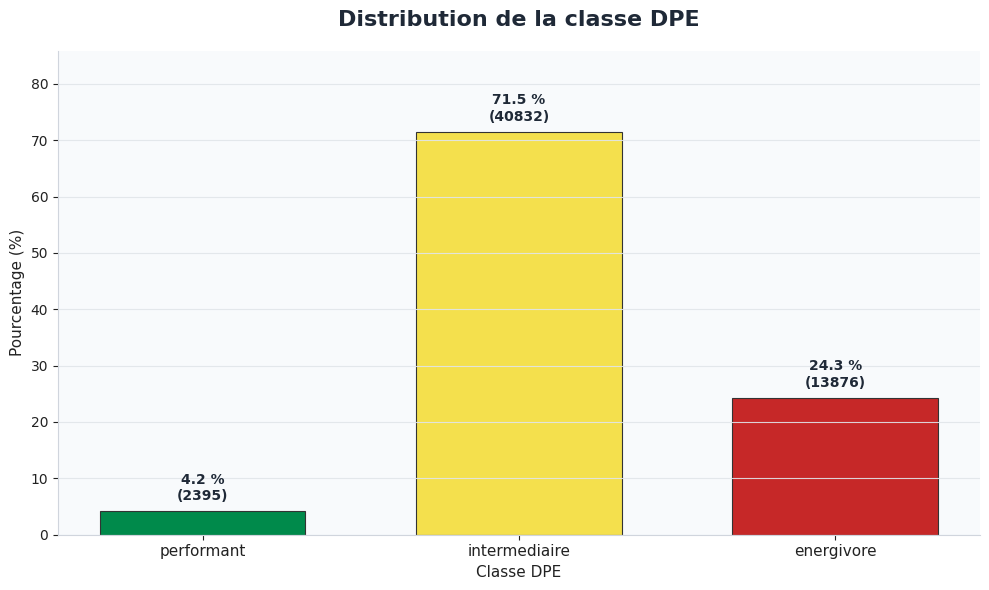

WindowsPath('src/plots/cat/distribution_classe_dpe_4.png')

In [33]:
plot_target_dpe(df, classes_dpe=NEW_CLASSES_DPE, dpe_colors=NEW_DPE_COLORS, target_col=NEW_TARGET)

# Préparation de l'analyse bivariée

## Regroupement des variables catégorielles

In [34]:
df = appliquer_regroupements_modalites(
    df=df,
    modalites_groupings=MODALITES_GROUPINGS
)

In [35]:
new_var_to_drop = list(MODALITES_GROUPINGS.keys()) + ["etiquette_dpe", "hauteur_sous_plafond", "numero_etage_appartement"]

var_to_drop = [*var_to_drop, *new_var_to_drop]

num_cols.remove("hauteur_sous_plafond")

In [36]:
colonnes_quali_regroupees = [
    f"{col}_regroupee"
    for col in MODALITES_GROUPINGS.keys()
]

colonnes_quali_regroupees

['zone_climatique_regroupee',
 'type_generateur_n1_installation_n1_regroupee',
 'type_emetteur_installation_chauffage_n1_regroupee',
 'type_generateur_n1_ecs_n1_regroupee',
 'type_energie_principale_chauffage_regroupee',
 'type_energie_principale_ecs_regroupee',
 'configuration_installation_chauffage_n1_regroupee']

## Checking des regroupements

In [37]:
controle_regroupements_modalites(
    df=df,
    colonnes_regroupees=colonnes_quali_regroupees
)

colonne,nb_modalites,missing_count,missing_%,autre_count,autre_%
str,i64,i64,f64,i64,f64
"""zone_climatique_regroupee""",3,0,0.0,0,0.0
"""type_generateur_n1_installation_n1_regroupee""",14,26,0.05,0,0.0
"""type_emetteur_installation_chauffage_n1_regroupee""",13,26,0.05,0,0.0
"""type_generateur_n1_ecs_n1_regroupee""",16,227,0.4,0,0.0
"""type_energie_principale_chauffage_regroupee""",7,0,0.0,0,0.0
"""type_energie_principale_ecs_regroupee""",8,0,0.0,0,0.0
"""configuration_installation_chauffage_n1_regroupee""",7,26,0.05,0,0.0


## Discrétisation de la variable production_electricite_pv_kwhep_par_an

### Distribution de la variable

In [38]:
resume_production_pv_positive(df)

nb_valeurs_positives,min,q25,mediane,q75,q90,q95,q99,max
u32,f32,f32,f32,f32,f32,f32,f32,f32
582,95.800003,818.099976,2138.600098,4938.299805,7502.600098,9646.099609,14688.0,460380.8125


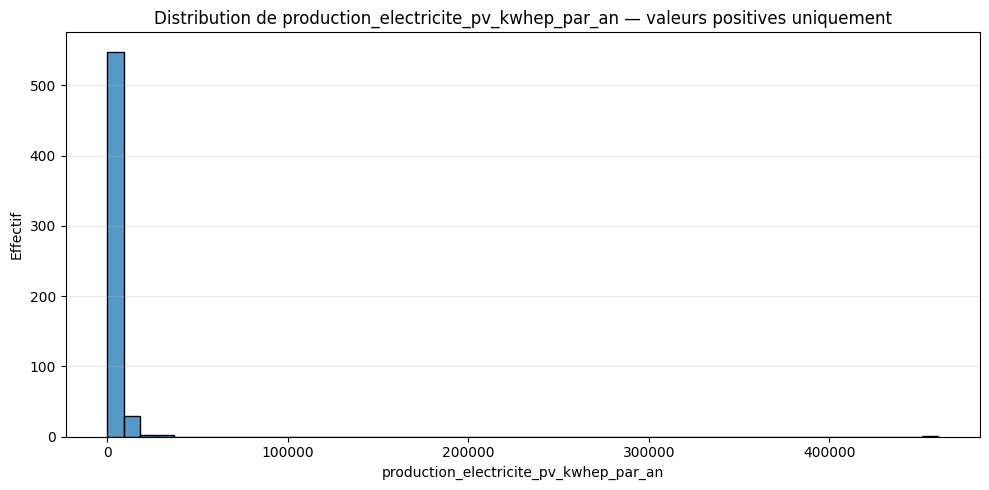

WindowsPath('src/plots/num/distribution_production_electricite_pv_kwhep_par_an_positives.png')

In [39]:
plot_dist(df, col="production_electricite_pv_kwhep_par_an", positive_only=True)

### Distribution sans le max

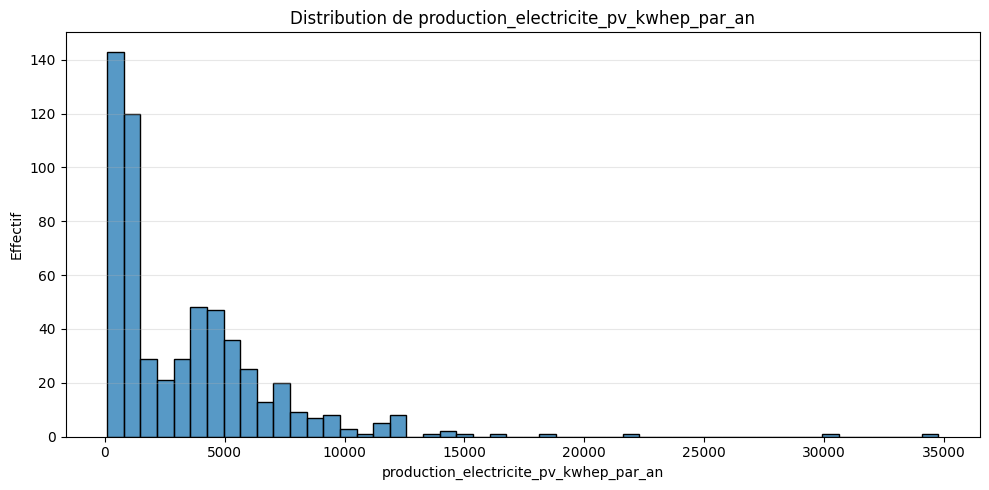

In [40]:
col = "production_electricite_pv_kwhep_par_an"

out_dir = Path("src/plots/num")
filename = f"Dist {col} without max"

fig_path = out_dir / filename

values = df.get_column(col).drop_nulls()

values = values.filter((values > 0) & (values < values.max()))

values = values.to_numpy()

fig, ax = plt.subplots(figsize=(10, 5), facecolor="white")

sns.histplot(
    values,
    bins=50,
    kde=False,
    ax=ax
)

titre = f"Distribution de {col}"

ax.set_title(titre)
ax.set_xlabel(col)
ax.set_ylabel("Effectif")
ax.grid(axis="y", alpha=0.3)

fig.tight_layout()

fig.savefig(
    fig_path,
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
    transparent=False,
)

plt.show()


### Discrétidation avec Kmeans

#### Train test split

In [41]:
train_df, test_df = split_train_test_polars(
    df,
    target="classe_dpe_4",
    test_size=0.2,
    random_state=42
)

In [42]:
print("Train :", train_df.shape)
print("Test :", test_df.shape)

Train : (45682, 47)
Test : (11421, 47)


In [43]:
train_df[NEW_TARGET].value_counts(normalize=True)

classe_dpe_4,proportion
str,f64
"""intermediaire""",0.715052
"""energivore""",0.243006
"""performant""",0.041942


In [44]:
test_df[NEW_TARGET].value_counts(normalize=True)

classe_dpe_4,proportion
str,f64
"""performant""",0.04194
"""intermediaire""",0.715086
"""energivore""",0.242973


#### Seuil avec Elbow

In [45]:
k_means = KMeans(random_state=42)

In [46]:
X_pv = (
    train_df
    .filter(pl.col(col) > 0)
    .select(col)
    .to_numpy()
)

X_pv_log = np.log1p(X_pv)

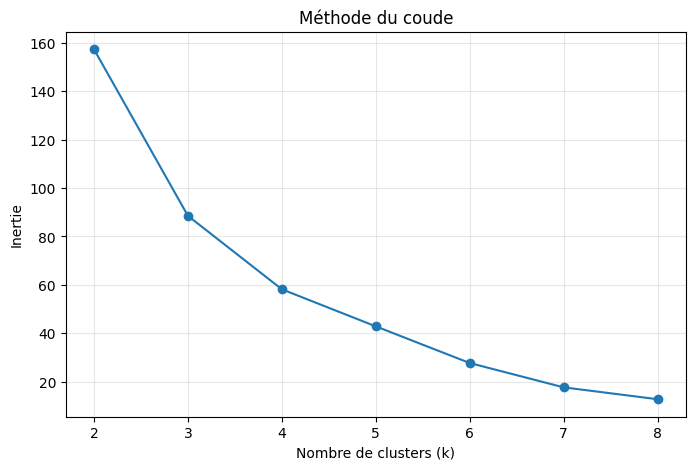

In [47]:
k_range, inertias = elbow_plot(
    X_pv_log,
    k_min=2,
    k_max=8
)

In [48]:
col_pv = "production_pv_kmeans"

In [49]:
kmeans_pv, mapping_pv = fit_kmeans_pv_train(
    train_df,
    col=col,
    n_clusters=3,
    random_state=42
)

# sur le train
train_df = appliquer_kmeans_pv(
    train_df,
    kmeans=kmeans_pv,
    mapping_cluster=mapping_pv,
    col=col
)

# Sur le test
test_df = appliquer_kmeans_pv(
    test_df,
    kmeans=kmeans_pv,
    mapping_cluster=mapping_pv,
    col=col
)

In [50]:
train_df[col_pv].value_counts(normalize=True)

production_pv_kmeans,proportion
str,f64
"""pv_moyenne""",0.003152
"""pv_faible""",0.002364
"""aucune_production_pv""",0.989711
"""pv_elevee""",0.004772


In [51]:
test_df[col_pv].value_counts(normalize=True)

production_pv_kmeans,proportion
str,f64
"""pv_elevee""",0.004991
"""aucune_production_pv""",0.990194
"""pv_faible""",0.002364
"""pv_moyenne""",0.002452


In [52]:
var_to_drop.append("production_electricite_pv_kwhep_par_an")

In [53]:
num_cols.remove("production_electricite_pv_kwhep_par_an")
num_cols

['numero_etage_appartement',
 'volume_stockage_generateur_n1_ecs_n1',
 'hauteur_sous_plafond_corrigee']

# Analyse Bivariée

### Proportion des logements énergivores par départment

In [54]:
taux_energivore_par_modalite(
    df,
    col="code_postal_ban",
    target=NEW_TARGET,
    min_effectif=50,
)

code_postal_ban,effectif_modalite,effectif_energivore,taux_energivore_%
str,u32,u32,f64
"""60270""",122,83,68.03
"""80400""",78,46,58.97
"""2140""",128,75,58.59
"""59570""",106,57,53.77
"""59138""",82,43,52.44
"""2800""",170,88,51.76
"""2300""",192,99,51.56
"""80200""",103,52,50.49
"""59158""",60,29,48.33


### Energie principale utilisée pour le chauffage par type de bâtiment

In [55]:
tableau_quali_quali(
    df,
    "type_batiment",
    "type_energie_principale_chauffage_regroupee"
)

type_batiment,type_energie_principale_chauffage_regroupee,effectif,effectif_col1,pourcentage_dans_col1
str,str,u32,u32,f64
"""appartement""","""Gaz naturel""",13590,27840,48.81
"""appartement""","""Électricité""",10043,27840,36.07
"""appartement""","""Réseau de chaleur""",3981,27840,14.3
"""appartement""","""Fioul domestique""",144,27840,0.52
"""appartement""","""Bois""",57,27840,0.2
"""appartement""","""GPL / Propane / Butane""",25,27840,0.09
"""immeuble""","""Gaz naturel""",863,1681,51.34
"""immeuble""","""Électricité""",659,1681,39.2
"""immeuble""","""Réseau de chaleur""",140,1681,8.33


### Un lien entre les variables numériques

In [56]:
num_cols

['numero_etage_appartement',
 'volume_stockage_generateur_n1_ecs_n1',
 'hauteur_sous_plafond_corrigee']

In [57]:
df[num_cols].drop_nulls().corr()

numero_etage_appartement,volume_stockage_generateur_n1_ecs_n1,hauteur_sous_plafond_corrigee
f64,f64,f64
1.0,-0.037472,-0.021237
-0.037472,1.0,0.044249
-0.021237,0.044249,1.0


### Des hauteurs de sous plafond diffèrent-elles entre les classes énergétiques ?

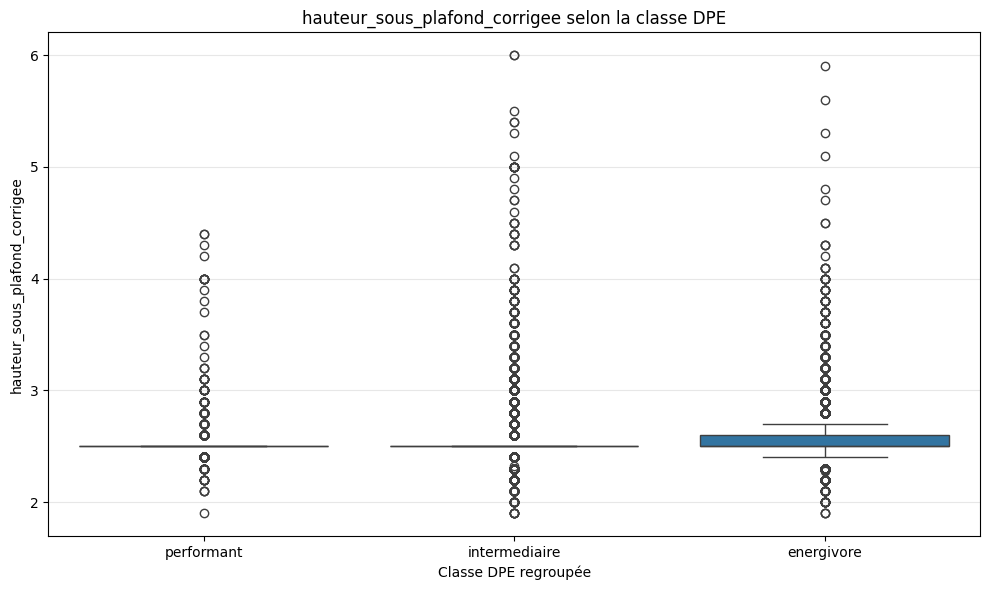

WindowsPath('src/plots/bivariee/boxplot_hauteur_sous_plafond_corrigee_vs_classe_dpe_4.png')

In [58]:
boxplot_vs_target(
    df,
    col="hauteur_sous_plafond_corrigee",
    target=NEW_TARGET,
    target_order=TARGET_ORDER
)

In [59]:
df["hauteur_sous_plafond_corrigee"].value_counts()

hauteur_sous_plafond_corrigee,count
f32,u32
2.9,1056
5.4,2
5.1,2
4.9,1
4.3,8
3.0,915
2.5,40686
5.6,1
2.28,1


# Tests Statistiques pour la sélection de variables

In [60]:
var_to_drop.remove(TARGET)
train_df = train_df.drop(var_to_drop)
test_df = test_df.drop(var_to_drop)
df = df.drop(var_to_drop)

cat_cols = list(set(cat_cols) - set(var_to_drop))
num_cols = list(set(num_cols) - set(var_to_drop))

In [61]:
quali_bin_cols, quanti_cols = separer_variables_quali_bin_quanti(
    df=train_df,
    target=TARGET,
    cols_a_exclure=[NEW_TARGET],
)

In [62]:
cat_cols = quali_bin_cols
num_cols = quanti_cols

In [63]:
resultats_tests = tester_variables_avec_target(
    df=train_df,
    target=NEW_TARGET,
    cat_cols=cat_cols,
    numeric_cols=num_cols,
    tester_missing=True,
)

resultats_tests_clean = resultats_tests.filter(
    pl.col("interpretation") != "aucun_missing"
)

resultats_variables = resultats_tests_clean.filter(
    ~pl.col("variable").str.ends_with("_missing")
)

resultats_variables

variable,type_variable,test,n,nb_modalites,statistique,p_value,taille_effet,effet,interpretation,nb_groupes
str,str,str,i64,i64,f64,f64,f64,str,str,i64
"""type_generateur_n1_ecs_n1_regroupee""","""qualitative""","""chi2""",45682,17,17378.4738,0.0,0.4361,"""cramers_v""","""forte""",null
"""type_generateur_n1_installation_n1_regroupee""","""qualitative""","""chi2""",45682,15,14868.7802,0.0,0.4034,"""cramers_v""","""forte""",null
"""qualite_isolation_enveloppe""","""qualitative""","""chi2""",45682,4,10470.545,0.0,0.3385,"""cramers_v""","""forte""",null
"""qualite_isolation_murs""","""qualitative""","""chi2""",45682,5,9573.1133,0.0,0.3237,"""cramers_v""","""forte""",null
"""ventilation_posterieure_2012""","""qualitative""","""chi2""",45682,2,4028.9027,0.0,0.297,"""cramers_v""","""moderee""",null
"""periode_construction""","""qualitative""","""chi2""",45682,10,7449.5387,0.0,0.2855,"""cramers_v""","""moderee""",null
"""qualite_isolation_menuiseries""","""qualitative""","""chi2""",45682,4,6065.1664,0.0,0.2577,"""cramers_v""","""moderee""",null
"""type_energie_principale_chauffage_regroupee""","""qualitative""","""chi2""",45682,7,4834.4547,0.0,0.23,"""cramers_v""","""moderee""",null
"""type_energie_principale_ecs_regroupee""","""qualitative""","""chi2""",45682,8,3459.7575,0.0,0.1946,"""cramers_v""","""moderee""",null


In [64]:
features_v1 =  [
    # Générateurs
    "type_generateur_n1_ecs_n1_regroupee",
    "type_generateur_n1_installation_n1_regroupee",

    # Isolation détaillée
    "qualite_isolation_murs",
    "qualite_isolation_menuiseries",
    "qualite_isolation_plancher_bas",

    # Ventilation / bâti
    "ventilation_posterieure_2012",
    "periode_construction",
    "type_batiment",

    # Énergies principales
    "type_energie_principale_chauffage_regroupee",
    "type_energie_principale_ecs_regroupee",

    # Émetteur chauffage
    "type_emetteur_installation_chauffage_n1_regroupee",

    # PV
    "has_PV",
]

In [65]:
features_v2 = [
    # Générateurs
    "type_generateur_n1_ecs_n1_regroupee",
    "type_generateur_n1_installation_n1_regroupee",

    # Isolation détaillée
    "qualite_isolation_murs",
    "qualite_isolation_menuiseries",
    "qualite_isolation_plancher_bas",

    # Ventilation / bâti
    "ventilation_posterieure_2012",
    "periode_construction",
    "type_batiment",
    "classe_inertie_batiment",

    # Chauffage
    "type_energie_principale_chauffage_regroupee",
    "type_emetteur_installation_chauffage_n1_regroupee",
    "configuration_installation_chauffage_n1_regroupee",
    "usage_generateur_n1_installation_n1",
    "type_installation_chauffage_n1",

    # ECS
    "type_energie_principale_ecs_regroupee",
    "usage_generateur_n1_ecs_n1",
    "type_installation_ecs_n1",
    "configuration_installation_ecs_n1",
    "volume_stockage_generateur_n1_ecs_n1",

    # Solaire / PV
    "has_PV",
    "production_pv_kmeans",
    "type_installation_solaire_n1",

    # Numérique
    "hauteur_sous_plafond_corrigee",

    # Autres
    "classe_altitude",
    "zone_climatique_regroupee",
]

In [66]:
variables_a_supprimer = [
    "numero_etage_appartement_corrige",
    "qualite_isolation_enveloppe",
]

In [67]:
train_df = train_df.drop(variables_a_supprimer)
test_df = test_df.drop(variables_a_supprimer)
df = df.drop(variables_a_supprimer)

cat_cols = list(set(cat_cols) - set(variables_a_supprimer))
num_cols = list(set(num_cols) - set(variables_a_supprimer))

# Preprocessing

In [68]:
X_train = train_df.drop(NEW_TARGET)
y_train = train_df[NEW_TARGET]
X_test = test_df.drop(NEW_TARGET)
y_test = test_df[NEW_TARGET]

## Gestion des valeurs manquantes 

### Visualation des valeurs manquantes par variable

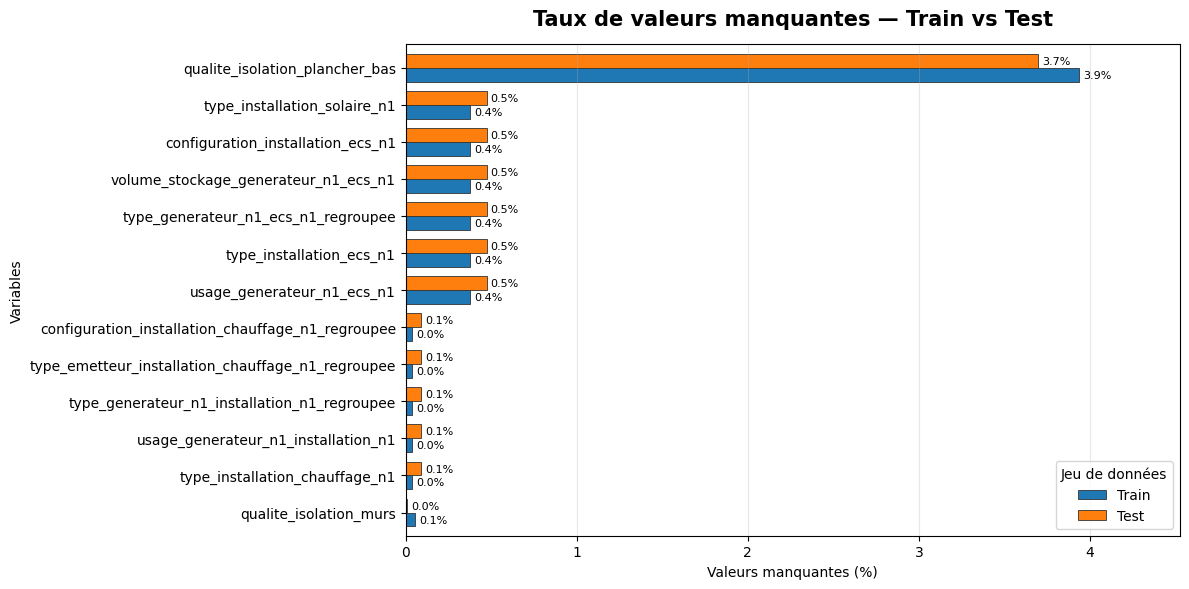

WindowsPath('src/plots/missing/missing_values_train_test.png')

In [69]:
plot_missing_train_test(
    X_train,
    X_test,
    only_missing=True,
    top_n=None,
    verbose=True,
)

### Remplacement des valeurs manquantes

In [70]:
features_v2 = [
    col for col in features_v2
    if col in train_df.columns
]

X_train = train_df.select(features_v2)
y_train = train_df[NEW_TARGET].to_numpy()

X_test = test_df.select(features_v2)
y_test = test_df[NEW_TARGET].to_numpy()

In [71]:
cat_cols_v = [
    col for col in cat_cols
    if col in X_train.columns
]

num_cols_v = [
    col for col in num_cols
    if col in X_train.columns
]

In [72]:
numeric_cols_missing = colonnes_avec_missing(
    X_train,
    num_cols_v
)

X_train = imputer_apres_selection(
    X_train,
    cat_cols=cat_cols_v,
    numeric_cols=num_cols_v,
    numeric_cols_missing=numeric_cols_missing,
)

X_test = imputer_apres_selection(
    X_test,
    cat_cols=cat_cols_v,
    numeric_cols=num_cols_v,
    numeric_cols_missing=numeric_cols_missing,
)

In [73]:
# Vérification
cols_miss = X_train.select(cs.ends_with("_missing")).columns

X_train.select(cols_miss).sum()

volume_stockage_generateur_n1_ecs_n1_missing
i64
173


# Pipeline : Encodage + Standardisation

## Avec les premières features pertinentes retenues

In [74]:
features_model = X_train.columns

cat_cols_model, binary_cols_model, numeric_cols_model = separer_colonnes_pipeline(
    X_train,
    features_model
)

In [75]:
cat_pipeline = Pipeline(
    steps=[
        ("encoder", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=True
        ))
    ]
)

num_pipeline = Pipeline(
    steps=[
        ("scaler", RobustScaler())
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", cat_pipeline, cat_cols_model),
        ("num", num_pipeline, numeric_cols_model),
        ("bin", "passthrough", binary_cols_model),
    ],
    remainder="drop"
)

In [76]:
X_train_pd = X_train.to_pandas()
X_test_pd = X_test.to_pandas()

## classification report

In [77]:
"""report_df = afficher_classification_report(
    y_test,
    y_pred,
    target_order=TARGET_ORDER,
)"""

'report_df = afficher_classification_report(\n    y_test,\n    y_pred,\n    target_order=TARGET_ORDER,\n)'

## Matrice de confusion

In [78]:
"""plot_confusion_matrix(
    y_test,
    y_pred,
    target_order=TARGET_ORDER,
    normalize=False,
)"""

'plot_confusion_matrix(\n    y_test,\n    y_pred,\n    target_order=TARGET_ORDER,\n    normalize=False,\n)'

In [79]:
"""plot_confusion_matrix(
    y_test,
    y_pred,
    target_order=TARGET_ORDER,
    normalize=True,
)"""

'plot_confusion_matrix(\n    y_test,\n    y_pred,\n    target_order=TARGET_ORDER,\n    normalize=True,\n)'

# LES MODELES

## LIGHTGBM

In [80]:
CLASS_WEIGHTS_TO_TEST = {
    "no_weight": None,

    "soft_1": {
        "performant": 2.5,
        "intermediaire": 1.0,
        "energivore": 1.2,
    },

    "soft_2": {
        "performant": 3.0,
        "intermediaire": 1.0,
        "energivore": 1.4,
    },

    "balanced_manual": {
        "performant": 4.0,
        "intermediaire": 1.0,
        "energivore": 1.5,
    },

    "recall_plus": {
        "performant": 5.0,
        "intermediaire": 1.0,
        "energivore": 1.8,
    },
}

In [81]:
lgb_params = {
    "n_estimators": 1050,
    "learning_rate": 0.008708419356114232,
    "max_depth": 13,
    "num_leaves": 258,
    "min_child_samples": 42,
    "subsample": 0.7762740808591235,
    "colsample_bytree": 0.594087067053412,
    "reg_alpha": 0.008385429549385955,
    "reg_lambda": 0.12026256069698821,
    "min_split_gain": 0.08502662659622719,
}

In [82]:
resultats_lgb = evaluer_lgb_class_weights(
    preprocessor=preprocessor,
    X_train_pd=X_train_pd,
    y_train=y_train,
    X_test_pd=X_test_pd,
    y_test=y_test,
    class_weights_to_test=CLASS_WEIGHTS_TO_TEST,
    lgb_params=lgb_params,
    target_order=TARGET_ORDER,
)

display(resultats_lgb.round(3))


===== Test : no_weight =====


D:\UTC\GI04\AI28\dpe\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


               precision    recall  f1-score   support

   performant      0.846     0.676     0.752       479
intermediaire      0.859     0.901     0.880      8167
   energivore      0.697     0.620     0.656      2775

     accuracy                          0.824     11421
    macro avg      0.801     0.733     0.763     11421
 weighted avg      0.819     0.824     0.820     11421


===== Test : soft_1 =====


D:\UTC\GI04\AI28\dpe\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


               precision    recall  f1-score   support

   performant      0.729     0.802     0.763       479
intermediaire      0.877     0.872     0.874      8167
   energivore      0.673     0.672     0.673      2775

     accuracy                          0.821     11421
    macro avg      0.759     0.782     0.770     11421
 weighted avg      0.821     0.821     0.821     11421


===== Test : soft_2 =====


...

D:\UTC\GI04\AI28\dpe\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


               precision    recall  f1-score   support

   performant      0.680     0.839     0.751       479
intermediaire      0.898     0.835     0.865      8167
   energivore      0.641     0.747     0.690      2775

     accuracy                          0.814     11421
    macro avg      0.740     0.807     0.769     11421
 weighted avg      0.827     0.814     0.818     11421


===== Test : recall_plus =====


D:\UTC\GI04\AI28\dpe\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


               precision    recall  f1-score   support

   performant      0.660     0.862     0.748       479
intermediaire      0.909     0.813     0.858      8167
   energivore      0.622     0.784     0.694      2775

     accuracy                          0.808     11421
    macro avg      0.730     0.820     0.766     11421
 weighted avg      0.829     0.808     0.814     11421



,modele,accuracy,balanced_accuracy,f1_macro,temps_sec,precision_performant,recall_performant,f1_performant,precision_intermediaire,recall_intermediaire,f1_intermediaire,precision_energivore,recall_energivore,f1_energivore
1,soft_1,0.821,0.782,0.770,29.6,0.729,0.802,0.763,0.877,0.872,0.874,0.673,0.672,0.673
2,soft_2,0.817,0.796,0.769,31.7,0.701,0.816,0.754,0.890,0.849,0.869,0.652,0.721,0.685
3,balanced_manual,0.814,0.807,0.769,28.6,0.680,0.839,0.751,0.898,0.835,0.865,0.641,0.747,0.690
4,recall_plus,0.808,0.820,0.766,29.2,0.660,0.862,0.748,0.909,0.813,0.858,0.622,0.784,0.694
0,no_weight,0.824,0.733,0.763,29.0,0.846,0.676,0.752,0.859,0.901,0.880,0.697,0.620,0.656


In [83]:
CLASS_WEIGHTS_TO_TEST_2 = {
    "very_soft_1": {
        "performant": 1.5,
        "intermediaire": 1.0,
        "energivore": 1.05,
    },

    "very_soft_2": {
        "performant": 1.8,
        "intermediaire": 1.0,
        "energivore": 1.10,
    },

    "very_soft_3": {
        "performant": 2.0,
        "intermediaire": 1.0,
        "energivore": 1.15,
    },

    "soft_precision": {
        "performant": 2.2,
        "intermediaire": 1.0,
        "energivore": 1.20,
    },
}

In [84]:
resultats_lgb_2 = evaluer_lgb_class_weights(
    preprocessor=preprocessor,
    X_train_pd=X_train_pd,
    y_train=y_train,
    X_test_pd=X_test_pd,
    y_test=y_test,
    class_weights_to_test=CLASS_WEIGHTS_TO_TEST_2,
    lgb_params=lgb_params,
    target_order=TARGET_ORDER,
)

display(resultats_lgb_2.round(3))


===== Test : very_soft_1 =====


D:\UTC\GI04\AI28\dpe\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


               precision    recall  f1-score   support

   performant      0.795     0.729     0.760       479
intermediaire      0.865     0.892     0.878      8167
   energivore      0.690     0.635     0.661      2775

     accuracy                          0.823     11421
    macro avg      0.783     0.752     0.767     11421
 weighted avg      0.819     0.823     0.821     11421


===== Test : very_soft_2 =====


D:\UTC\GI04\AI28\dpe\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


               precision    recall  f1-score   support

   performant      0.780     0.762     0.771       479
intermediaire      0.869     0.886     0.877      8167
   energivore      0.684     0.646     0.665      2775

     accuracy                          0.823     11421
    macro avg      0.777     0.765     0.771     11421
 weighted avg      0.820     0.823     0.821     11421


===== Test : very_soft_3 =====


D:\UTC\GI04\AI28\dpe\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


               precision    recall  f1-score   support

   performant      0.760     0.781     0.770       479
intermediaire      0.873     0.880     0.876      8167
   energivore      0.679     0.658     0.668      2775

     accuracy                          0.822     11421
    macro avg      0.770     0.773     0.772     11421
 weighted avg      0.821     0.822     0.821     11421


===== Test : soft_precision =====


D:\UTC\GI04\AI28\dpe\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


               precision    recall  f1-score   support

   performant      0.749     0.791     0.770       479
intermediaire      0.876     0.874     0.875      8167
   energivore      0.673     0.671     0.672      2775

     accuracy                          0.821     11421
    macro avg      0.766     0.779     0.772     11421
 weighted avg      0.821     0.821     0.821     11421



,modele,accuracy,balanced_accuracy,f1_macro,temps_sec,precision_performant,recall_performant,f1_performant,precision_intermediaire,recall_intermediaire,f1_intermediaire,precision_energivore,recall_energivore,f1_energivore
3,soft_precision,0.821,0.779,0.772,29.7,0.749,0.791,0.770,0.876,0.874,0.875,0.673,0.671,0.672
2,very_soft_3,0.822,0.773,0.772,25.4,0.760,0.781,0.770,0.873,0.880,0.876,0.679,0.658,0.668
1,very_soft_2,0.823,0.765,0.771,46.6,0.780,0.762,0.771,0.869,0.886,0.877,0.684,0.646,0.665
0,very_soft_1,0.823,0.752,0.767,30.9,0.795,0.729,0.760,0.865,0.892,0.878,0.690,0.635,0.661
